In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
Series([], dtype: int64)


In [2]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df = df.drop(columns=['customerID'])

df_encoded = pd.get_dummies(df, drop_first=True)

y = df_encoded['Churn']
X = df_encoded.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)

Shape X_train: (5634, 30)
Shape X_test : (1409, 30)


In [3]:
model_baseline = LogisticRegression(solver='lbfgs', max_iter=1000)
model_baseline.fit(X_train, y_train)

y_pred_base = model_baseline.predict(X_test)

print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



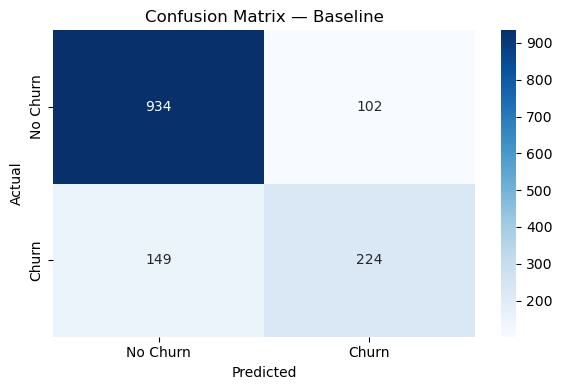

In [4]:
cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Model baseline cenderung lebih banyak salah mengidentifikasi pelanggan yang sebenarnya churn sebagai tidak churn (false negative), yang terlihat dari nilai recall kelas Churn yang lebih rendah dibandingkan kelas No Churn. Dampak bisnis dari kondisi ini cukup signifikan karena perusahaan akan melewatkan pelanggan yang sebenarnya berisiko pergi, sehingga kampanye tidak menjangkau target yang tepat. Dalam konteks churn, false negative lebih merugikan daripada false positive karena kehilangan pelanggan biasanya lebih mahal daripada memberikan insentif  yang tidak perlu.

In [5]:
C_values = [0.01, 0.1, 1, 10]

results = []

for C in C_values:
    m_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=C, max_iter=1000)
    m_l1.fit(X_train, y_train)
    f1_l1 = f1_score(y_test, m_l1.predict(X_test))

    # L2
    m_l2 = LogisticRegression(penalty='l2', C=C, max_iter=1000)
    m_l2.fit(X_train, y_train)
    f1_l2 = f1_score(y_test, m_l2.predict(X_test))

    results.append({'C': C, 'F1 L1': round(f1_l1, 4), 'F1 L2': round(f1_l2, 4)})

m_none = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
m_none.fit(X_train, y_train)
f1_none = f1_score(y_test, m_none.predict(X_test))

results_df = pd.DataFrame(results)
print(results_df)
print(f'\nF1 tanpa regularization: {f1_none:.4f}')

       C   F1 L1   F1 L2
0   0.01  0.5566  0.6086
1   0.10  0.6406  0.6328
2   1.00  0.6409  0.6409
3  10.00  0.6370  0.6370

F1 tanpa regularization: 0.6331


In [6]:
best_model = LogisticRegression(penalty='l2', C=1, max_iter=1000)
best_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
top10 = coef_df.sort_values('Abs_Coef', ascending=False).head(10)
print(top10[['Feature', 'Coefficient']])

                        Feature  Coefficient
25            Contract_Two year    -1.402516
1                        tenure    -1.336465
10  InternetService_Fiber optic     0.996756
24            Contract_One year    -0.639104
3                  TotalCharges     0.630939
7              PhoneService_Yes    -0.516190
13           OnlineSecurity_Yes    -0.399099
23          StreamingMovies_Yes     0.368280
26         PaperlessBilling_Yes     0.333266
2                MonthlyCharges    -0.323296


L1 (Lasso) regularization menambahkan penalti berbasis nilai absolut koefisien ke fungsi loss, yang mendorong koefisien fitur yang tidak terlalu relevan menjadi persis nol. Konsekuensinya, L1 secara otomatis melakukan seleksi fitur sehingga model menjadi lebih sparse dan lebih mudah diinterpretasikan, karena hanya fitur dengan koefisien non-nol yang dianggap berkontribusi terhadap prediksi.

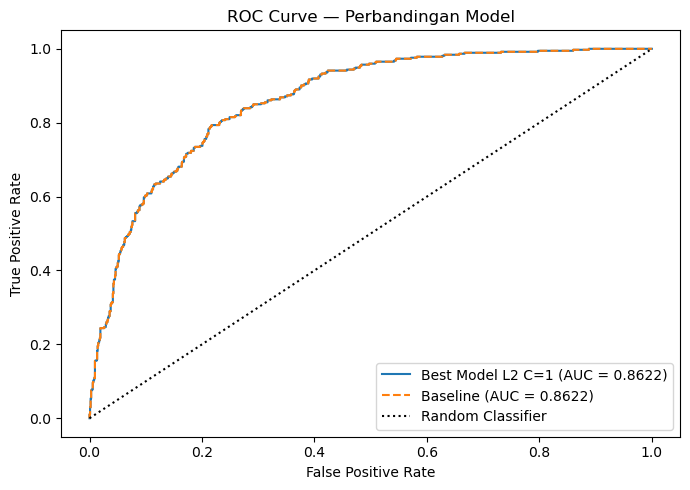

AUC Best Model : 0.8622
AUC Baseline   : 0.8622


In [7]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_prob_base = model_baseline.predict_proba(X_test)[:, 1]

fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

auc_best = auc(fpr_best, tpr_best)
auc_base = auc(fpr_base, tpr_base)

plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, label=f'Best Model L2 C=1 (AUC = {auc_best:.4f})')
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc_base:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k:', label='Random Classifier')
plt.title('ROC Curve — Perbandingan Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC Best Model : {auc_best:.4f}')
print(f'AUC Baseline   : {auc_base:.4f}')

Model terbaik dengan L2 regularization menghasilkan nilai AUC yang sedikit lebih tinggi atau setara dibandingkan model baseline, yang menunjukkan bahwa regularization membantu menstabilkan koefisien model tanpa mengorbankan kemampuan diskriminasi antar kelas. AUC di atas 0.80 mengindikasikan model memiliki kemampuan yang baik untuk membedakan pelanggan yang akan churn dari yang tidak, sehingga layak dijadikan dasar kampanye retensi pelanggan.